# 📈 Seguimiento de experimentos con MLflow — Student Depression

Este notebook entrena y **registra en MLflow** los modelos base de `02_modeling.ipynb`
y sus versiones **ajustadas** (`03_tuning.ipynb`), para poder comparar todos los
experimentos desde la UI de MLflow (parámetros, métricas, artefactos y el pipeline
completo versionado).

> ⚠️ **Nota ética:** el modelo resultante es una herramienta de **análisis estadístico**
> con fines académicos, **no** un instrumento de diagnóstico clínico.

## 1. Configuración

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import mlflow
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split

from src.config.constants import RANDOM_STATE
from src.config.mlflow_setup import EXPERIMENT_NAME, set_tracking
from src.data.loaders import load_raw_data
from src.features.engineering import split_X_y
from src.models.train import get_models
from src.models.train_mlflow import TUNED_PARAMS, train_and_log

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

set_tracking()
print(f"Tracking URI : {mlflow.get_tracking_uri()}")
print(f"Experimento  : {EXPERIMENT_NAME}")

2026/09/22 20:51:38 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at C:\ProyectoAprendizajeEnNube\.venv\Lib\site-packages\mlflow\assistant\skills\instrumenting-with-mlflow-tracing\SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


2026/09/22 20:51:41 INFO mlflow.tracking.fluent: Experiment with name 'student-depression' does not exist. Creating a new experiment.


Tracking URI : file:///C:/ProyectoAprendizajeEnNube/mlruns
Experimento  : student-depression


## 2. Carga y split

Mismo `train_test_split` (semilla y estratificación) que en `02_modeling.ipynb` y
`03_tuning.ipynb`, para que los runs sean comparables entre notebooks.

In [2]:
df = load_raw_data()
X, y = split_X_y(df)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}")

Train: 22,320  |  Test: 5,581


## 3. Entrenar y loguear los modelos base

Para cada modelo de `get_models()` entrenamos el `Pipeline` completo
(preprocesador + modelo) y registramos un run de MLflow con `train_and_log`
(`src/models/train_mlflow.py`), que loguea parámetros, métricas, el pipeline
y artefactos (matriz de confusión y curva ROC).

In [3]:
baseline_run_ids = {}
for name, model in get_models().items():
    run_id = train_and_log(
        name, model, X_train, y_train, X_test, y_test,
        run_name=f"{name} (baseline)", extra_tags={"stage": "baseline"},
    )
    baseline_run_ids[name] = run_id
    print(f"[baseline] {name}: run_id={run_id}")

2026/09/22 20:51:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/09/22 20:51:49 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


[baseline] Logistic Regression: run_id=29ce86c7687943b4a4cc0091bd898fdc


2026/09/22 20:51:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/09/22 20:51:55 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


[baseline] Decision Tree: run_id=0422d1b61fd5400aa0366819450ef823


2026/09/22 20:51:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/09/22 20:52:03 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


[baseline] Random Forest: run_id=9f34d5beb82347959d4d2390b0aca3e0


## 4. Entrenar y loguear los modelos ya tuneados

Reutilizamos los mejores hiperparámetros encontrados en `03_tuning.ipynb`
(`GridSearchCV` / `RandomizedSearchCV` optimizando F1), guardados en
`TUNED_PARAMS` dentro de `train_mlflow.py`, y los registramos como runs
aparte (`stage=tuned`) para compararlos con el baseline.

In [4]:
tuned_run_ids = {}
for name, model in get_models().items():
    tuned_model = model.__class__(**{**model.get_params(), **TUNED_PARAMS[name]})
    run_id = train_and_log(
        name, tuned_model, X_train, y_train, X_test, y_test,
        run_name=f"{name} (tuned)", extra_tags={"stage": "tuned"},
    )
    tuned_run_ids[name] = run_id
    print(f"[tuned]    {name}: run_id={run_id}")

C:\ProyectoAprendizajeEnNube\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


2026/09/22 20:52:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/09/22 20:52:09 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


[tuned]    Logistic Regression: run_id=ed996dee67d64b89828efabddc41473e


2026/09/22 20:52:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/09/22 20:52:15 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


[tuned]    Decision Tree: run_id=c36832b9398f4faba11cbcffb357f064


2026/09/22 20:52:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/09/22 20:52:22 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


[tuned]    Random Forest: run_id=e79ba99a00734856bb1f9e0633dce132


## 5. Comparar runs desde el notebook

`mlflow.search_runs` trae todos los runs del experimento como un DataFrame,
con columnas `metrics.*`, `params.*` y `tags.*`. Es la forma programática de
comparar experimentos sin salir del notebook.

In [5]:
runs_df = mlflow.search_runs(experiment_names=[EXPERIMENT_NAME])

summary = runs_df[[
    "tags.mlflow.runName", "tags.stage", "params.model_name",
    "metrics.accuracy", "metrics.f1", "metrics.roc_auc", "metrics.recall_pos",
]].rename(columns={
    "tags.mlflow.runName": "run",
    "tags.stage": "stage",
    "params.model_name": "modelo",
    "metrics.accuracy": "accuracy",
    "metrics.f1": "f1",
    "metrics.roc_auc": "roc_auc",
    "metrics.recall_pos": "recall_pos",
})
summary = summary.sort_values("f1", ascending=False).reset_index(drop=True)
summary.round(4)

,run,stage,modelo,accuracy,f1,roc_auc,recall_pos
0,Logistic Regression (tuned),tuned,Logistic Regression,0.8438,0.8685,0.9188,0.8813
1,Logistic Regression (baseline),baseline,Logistic Regression,0.8436,0.8681,0.9184,0.8788
2,Random Forest (baseline),baseline,Random Forest,0.8384,0.8653,0.9134,0.8865
3,Random Forest (tuned),tuned,Random Forest,0.8384,0.8653,0.9134,0.8865
4,Decision Tree (tuned),tuned,Decision Tree,0.8258,0.8542,0.8917,0.8715
5,Decision Tree (baseline),baseline,Decision Tree,0.8257,0.8529,0.8895,0.8632


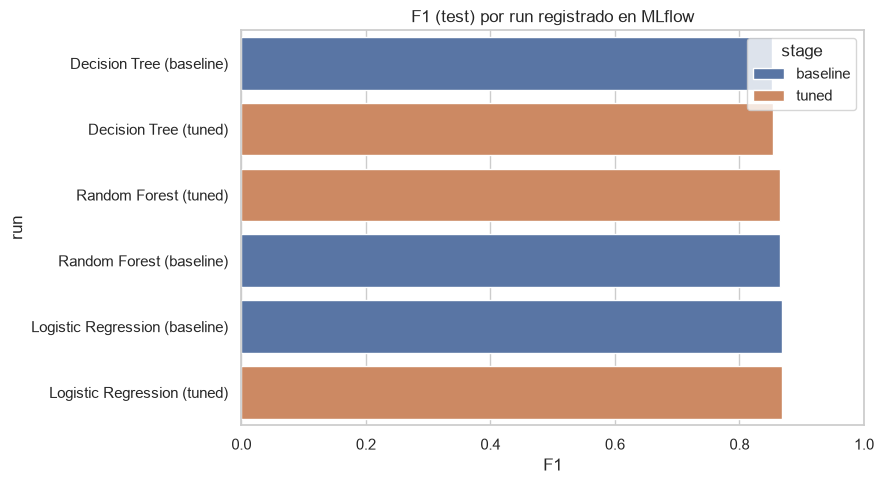

In [6]:
ax = sns.barplot(
    data=summary.sort_values("f1"), x="f1", y="run", hue="stage", dodge=False,
)
ax.set_title("F1 (test) por run registrado en MLflow")
ax.set_xlabel("F1")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

## 6. Comparar runs en la UI de MLflow

Desde una terminal, en la raíz del proyecto:

```bash
uv run mlflow ui --backend-store-uri ./mlruns
```

Y abrir **http://localhost:5000** en el navegador. Ahí se puede:

- Ver el experimento **`student-depression`** con todos los runs (baseline y tuned).
- **Seleccionar varios runs** y comparar parámetros/métricas lado a lado, o con
  gráficos de coordenadas paralelas.
- Abrir un run y descargar sus **artefactos** (matriz de confusión, curva ROC) o el
  **pipeline** logueado (`mlflow.sklearn.log_model`), listo para volver a cargar con
  `mlflow.sklearn.load_model(...)`.

> En Windows, si `MLFLOW_ALLOW_FILE_STORE` no está activo, MLflow puede rechazar el
> backend de archivos `./mlruns` (lo pone en modo mantenimiento desde MLflow 3).
> `src/config/mlflow_setup.py` ya fija esa variable de entorno al importar el módulo,
> pero si se lanza `mlflow ui` desde una terminal nueva puede hacer falta fijarla a mano:
>
> ```powershell
> $env:MLFLOW_ALLOW_FILE_STORE = "true"
> uv run mlflow ui --backend-store-uri ./mlruns
> ```

## 7. Conclusiones

- MLflow registra, para cada run, los **hiperparámetros**, las **métricas** en test
  (accuracy, F1, ROC-AUC, recall de la clase positiva), el **pipeline** completo
  (preprocesador + modelo) y **artefactos** gráficos (matriz de confusión, curva ROC).
- Comparar `stage=baseline` vs `stage=tuned` en la tabla/gráfico anterior reproduce,
  con trazabilidad completa, la misma conclusión de `03_tuning.ipynb`: el ajuste de
  hiperparámetros aporta una mejora marginal sobre un baseline ya competitivo.
- Con el historial en `./mlruns`, cualquier run puede recargarse más adelante
  (`mlflow.sklearn.load_model(f"runs:/<run_id>/pipeline")`) sin tener que reentrenar.

> ⚠️ **Recordatorio ético:** este modelo es una herramienta de **análisis estadístico**
> con fines académicos, **no** un diagnóstico clínico; cualquier uso real exige
> validación profesional y supervisión humana.